In [1]:
# from roboflow import Roboflow
# rf = Roboflow(api_key="L6l28LkjEGy2UNNAVhIL")
# project = rf.workspace("plasticbeaching").project("plastic_beaching")
# version = project.version(1)
# dataset = version.download("yolov5")

In [2]:
import zipfile
import os
import json
from ultralytics import YOLO  # Assuming you installed the ultralytics package locally

# # Unzip the dataset
# zip_path = "C:/Users/lswus/Documents/A_MasterThesis/DeepCutLab/pb_2.v2i.yolov5pytorch.zip"  # Path to your zip file
# extract_path = "C:/Users/lswus/Documents/A_MasterThesis/DeepCutLab/"  # Path to where you want to extract the dataset

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Dataset unzipped!")

# # Setting the YOLO model
# model = YOLO("yolov8n.pt")  # Local path to the YOLO model

# # Train the model
# results = model.train(data="C:/Users/lswus/Documents/A_MasterThesis/DeepCutLab/data.yaml", epochs=30, imgsz=640)



In [3]:
model = YOLO('C:/Users/lswus/Documents/A_MasterThesis/DeepCutLab/runs/detect/train6/weights/best.pt')

In [4]:
 # place were my file is stored: C:\Users\lswus\anaconda3\envs\Tracking\Lib\site-packages\ultralytics\cfg\trackers\


In [5]:
# source_vid = 'C:/Users/lswus/Documents/A_MasterThesis/DeepCutLab/Testvideos/Test_Vid_Yellowball_Middle_inshade.mp4'
# # results = model.track(source = source_vid, tracker="bytetrack.yaml", save=True, save_txt = True, conf=0.2)

# results = model.track(
#     source=source_vid, 
#     tracker="botsort.yaml",  
#     save=True, 
#     save_txt=True, 
#     conf=0.3
# )



In [6]:
# import yaml
# import os

# # Path to the ByteTrack YAML configuration file
# yaml_file_path = r'C:\Users\lswus\anaconda3\envs\Tracking\Lib\site-packages\ultralytics\cfg\trackers\bytetrack.yaml'

# # Load the YAML file to print its contents
# with open(yaml_file_path, 'r') as file:
#     bytetrack_config = yaml.safe_load(file)

# # Print the values in the ByteTrack YAML configuration file
# print("ByteTrack Configuration:")
# for key, value in bytetrack_config.items():
#     print(f"{key}: {value}")

# # Now you can run your model track
# source_vid = 'C:/Users/lswus/Documents/A_MasterThesis/DeepCutLab/Testvideos/Test_Manyparticles_End.mp4'
# results = model.track(
#     source=source_vid, 
#     tracker=yaml_file_path,  # Using the absolute path to the YAML file
#     save=True, 
#     save_txt=True, 
#     conf=0.25
# )


In [7]:
# %matplotlib inline
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt


# # Directory where the .txt files are stored
# txt_dir = "C:/Users/lswus/Documents/A_MasterThesis/DeepCutLab/runs/detect/track15/labels"

# # Initialize an empty list to store data
# data = []

# # Frame rate (30 frames per second)
# fps = 30

# # Loop through all the txt files in the directory
# for filename in os.listdir(txt_dir):
#     if filename.endswith(".txt"):
#         # Extract frame number from the filename (e.g., "Videoproject 30_951.txt" -> 951)
#         frame_num = int(filename.split('_')[-1].split('.')[0])

#         # Read the first line of the txt file (the first row of detections)
#         with open(os.path.join(txt_dir, filename), 'r') as file:
#             first_line = file.readline().strip()
#             if first_line:
#                 # Parse the data: class_id, x_center, y_center, width, height, object_id
#                 data_parts = first_line.split()
#                 class_id = int(data_parts[0])
#                 x_center = float(data_parts[1])
#                 y_center = float(data_parts[2])
#                 width = float(data_parts[3])
#                 height = float(data_parts[4])

#                 # Initialize id_number as NaN
#                 id_number = np.nan

#                 # Try to get the id_number (if available)
#                 try:
#                     id_number = float(data_parts[5])
#                 except IndexError:
#                     pass  # If no id_number, it will remain NaN

#                 # Calculate the real time (in seconds)
#                 real_time = frame_num / fps

#                 # Append the data as a dictionary to the data list
#                 data.append({
#                     "Frame": frame_num,
#                     "Real_Time(s)": real_time,
#                     "Class_ID": class_id,
#                     "X_Center": x_center,
#                     "Y_Center": y_center,
#                     "Width": width,
#                     "Height": height,
#                     'Id_number': id_number
#                 })

# # Convert the list of dictionaries into a pandas DataFrame
# df = pd.DataFrame(data)

# # Sort the DataFrame by the 'Frame' column (ascending order)
# df_sorted = df.sort_values(by='Frame').reset_index(drop=True)

# # Convert the normalized X_Center to real-world distance (in cm)
# real_width = 292  # real-world width in cm
# real_y = 292 * (384/640)
# df_sorted['Real_X'] = df_sorted['X_Center'] * real_width
# df_sorted['Real_Y'] = df_sorted['Y_Center'] * real_y

# # Print the updated dataframe to check
# # print(df_sorted)


In [8]:
# # Create a new dataframe with only the time, Real_X, and Real_Y columns
# df_flipped = df_sorted[['Id_number', 'Real_Time(s)', 'Real_X', 'Real_Y']].copy()
# print(df_flipped[100:150])

# # # Flip the Real_X and Real_Y to set the origin at the bottom right
# df_flipped['Real_X'] = np.abs(df_flipped['Real_X'] - df_flipped['Real_X'][0])  # Flip the X-axis
# df_flipped['Real_Y'] = 292 * (384/640) - df_flipped['Real_Y']  # Flip the Y-axis

# # Plot the flipped data
# plt.plot(df_flipped['Real_X'], df_flipped['Real_Y'], marker='.')
# plt.plot(df_flipped['Real_X'][0], df_flipped['Real_Y'][0], marker='o', color='green')
# plt.plot(df_flipped['Real_X'][-1:], df_flipped['Real_Y'][-1:], marker='o', color='red')
# # Set x-axis ticks from 0 to 2.92 with intervals of 0.50
# plt.xticks(np.arange(0, 300, 50))
# plt.yticks(np.arange(0, 150, 50))
# # Add labels and title
# plt.xlabel('Real X Position (cm)')
# plt.ylabel('Real Y Position (cm)')
# plt.title('Particle Tracking: Flipped X vs Y Positions')

# plt.show()


# # Plot the flipped data
# plt.plot(df_flipped['Real_Time(s)'], df_flipped['Real_X'], marker='.')
# plt.plot(df_flipped['Real_Time(s)'][0], df_flipped['Real_X'][0], marker='o', color='green')
# plt.plot(df_flipped['Real_Time(s)'][-1:], df_flipped['Real_X'][-1:], marker='o', color='red')

# plt.xlabel('Real_Time(s)')
# plt.ylabel('Real X Position (cm)')
# plt.title('Particle Tracking: distance over time')



# # Show the plot
# plt.show()


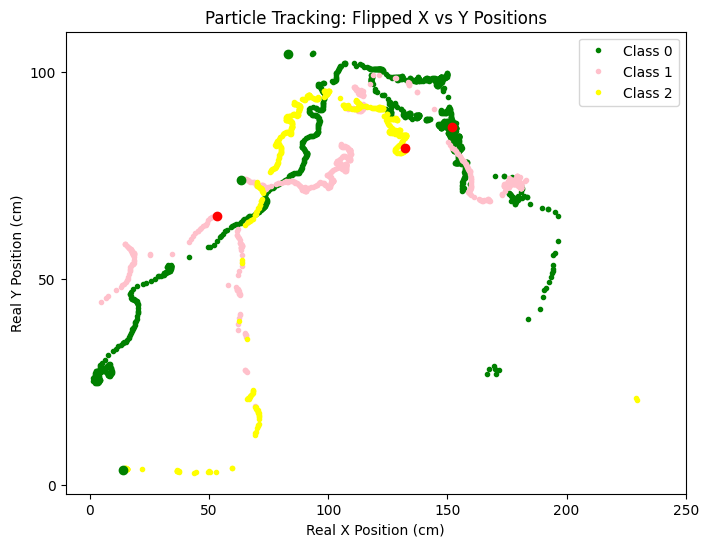

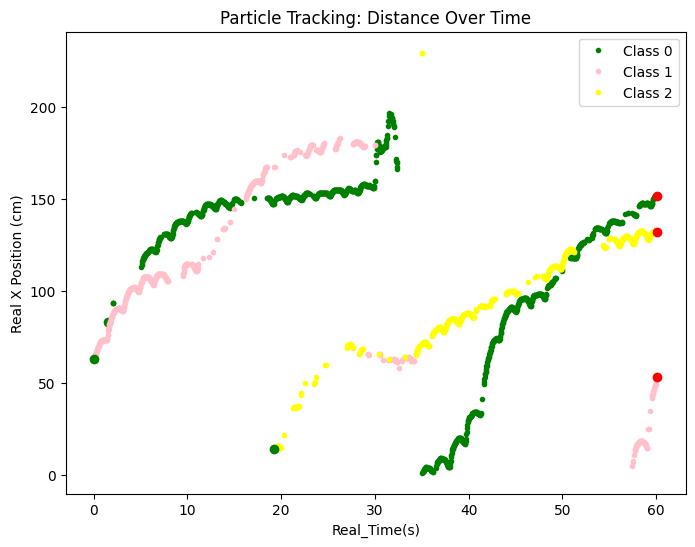

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Directory where the .txt files are stored
txt_dir = "C:/Users/lswus/Documents/A_MasterThesis/DeepCutLab/runs/detect/track15/labels"

# Initialize an empty list to store data
data = []

# Frame rate (30 frames per second)
fps = 30

# Loop through all the txt files in the directory
for filename in os.listdir(txt_dir):
    if filename.endswith(".txt"):
        # Extract frame number from the filename
        frame_num = int(filename.split('_')[-1].split('.')[0])
        real_time = frame_num / fps
        
        # Read all lines in the txt file
        with open(os.path.join(txt_dir, filename), 'r') as file:
            for line in file:
                data_parts = line.strip().split()
                if len(data_parts) >= 5:
                    class_id = int(data_parts[0])
                    x_center = float(data_parts[1])
                    y_center = float(data_parts[2])
                    width = float(data_parts[3])
                    height = float(data_parts[4])
                    
                    # Try to get the id_number (if available)
                    id_number = np.nan
                    if len(data_parts) > 5:
                        try:
                            id_number = float(data_parts[5])
                        except ValueError:
                            pass
                    
                    # Append the data as a dictionary to the list
                    data.append({
                        "Frame": frame_num,
                        "Real_Time(s)": real_time,
                        "Class_ID": class_id,
                        "X_Center": x_center,
                        "Y_Center": y_center,
                        "Width": width,
                        "Height": height,
                        "Id_number": id_number
                    })

# Convert the list into a DataFrame
df = pd.DataFrame(data)

# Convert the normalized X_Center to real-world distance (in cm)
real_width = 260  # real-world width in cm
real_y = 260 * (384/640)
df['Real_X'] = df['X_Center'] * real_width
df['Real_Y'] = df['Y_Center'] * real_y

# Sort DataFrame by time
df_sorted = df.sort_values(by=['Real_Time(s)']).reset_index(drop=True)

# Flip the coordinates
df_sorted['Flipped_Real_X'] = np.abs(df_sorted['Real_X'] - 260)
df_sorted['Flipped_Real_Y'] = real_y - df_sorted['Real_Y']

# Create a sorted DataFrame for plotting
df_flipped = df_sorted[['Id_number', 'Real_Time(s)', 'Flipped_Real_X', 'Flipped_Real_Y']].copy()

# Define class colors
class_colors = {0: 'green', 1: 'pink', 2: 'yellow'}

# Identify misclassified 'pink' points
pink_df = df_sorted[df_sorted['Class_ID'] == 1]
yellow_df = df_sorted[df_sorted['Class_ID'] == 2]

# Merge datasets to find temporal overlaps
merged = pink_df.merge(yellow_df, on='Real_Time(s)', suffixes=('_pink', '_yellow'))

# Compute distance between pink and yellow points at the same timestamp
distance_threshold = 5  # Define an appropriate threshold
merged['distance'] = np.sqrt(
    (merged['Flipped_Real_X_pink'] - merged['Flipped_Real_X_yellow'])**2 +
    (merged['Flipped_Real_Y_pink'] - merged['Flipped_Real_Y_yellow'])**2
)

# Identify misclassified points
to_drop = merged[merged['distance'] < distance_threshold].index

# Drop those points from the main dataset
df_filtered = df_sorted.drop(to_drop).reset_index(drop=True)

# Plot each class separately
plt.figure(figsize=(8, 6))
for class_id, color in class_colors.items():
    class_df = df_filtered[df_filtered['Class_ID'] == class_id]
    plt.plot(class_df['Flipped_Real_X'], class_df['Flipped_Real_Y'], marker='.', linestyle='', color=color, label=f'Class {class_id}')
    plt.plot(class_df['Flipped_Real_X'].iloc[0], class_df['Flipped_Real_Y'].iloc[0], marker='o', color='green')
    plt.plot(class_df['Flipped_Real_X'].iloc[-1], class_df['Flipped_Real_Y'].iloc[-1], marker='o', color='red')

plt.xticks(np.arange(0, 300, 50))
plt.yticks(np.arange(0, 150, 50))
plt.xlabel('Real X Position (cm)')
plt.ylabel('Real Y Position (cm)')
plt.title('Particle Tracking: Flipped X vs Y Positions')
plt.legend()
plt.show()

# Plot distance over time for each class
plt.figure(figsize=(8, 6))
for class_id, color in class_colors.items():
    class_df = df_filtered[df_filtered['Class_ID'] == class_id]
    plt.plot(class_df['Real_Time(s)'], class_df['Flipped_Real_X'], marker='.', linestyle='', color=color, label=f'Class {class_id}')
    plt.plot(class_df['Real_Time(s)'].iloc[0], class_df['Flipped_Real_X'].iloc[0], marker='o', color='green')
    plt.plot(class_df['Real_Time(s)'].iloc[-1], class_df['Flipped_Real_X'].iloc[-1], marker='o', color='red')

plt.xlabel('Real_Time(s)')
plt.ylabel('Real X Position (cm)')
plt.title('Particle Tracking: Distance Over Time')
plt.legend()
plt.show()


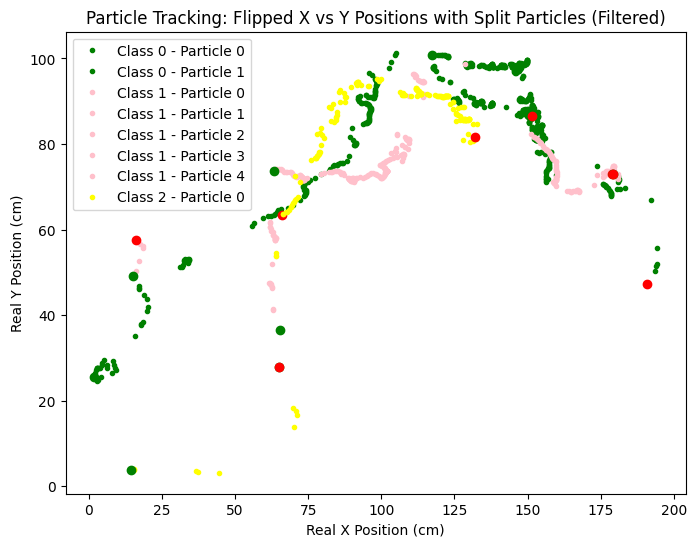

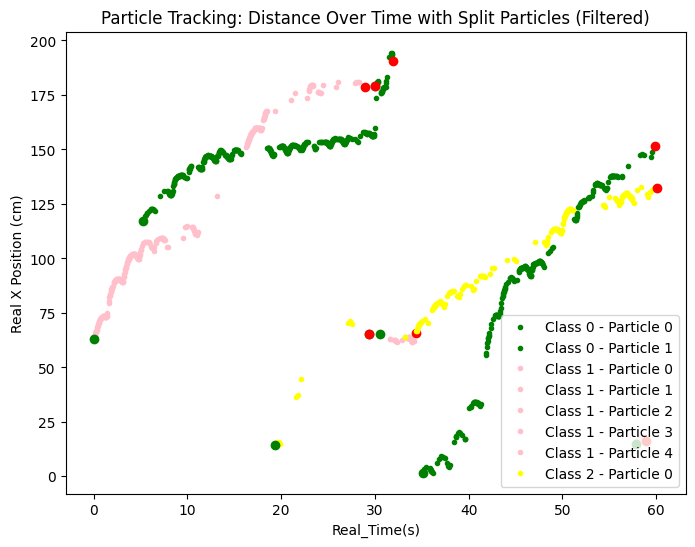

In [10]:
# Sort DataFrame by time
df_sorted = df.sort_values(by=['Real_Time(s)']).reset_index(drop=True)

# Flip the coordinates
df_sorted['Flipped_Real_X'] = np.abs(df_sorted['Real_X'] - 260)
df_sorted['Flipped_Real_Y'] = real_y - df_sorted['Real_Y']

# Define threshold for removing outliers (5 cm in X and Y)
position_threshold = 5  # cm

# Create a mask to keep only valid points
valid_indices = []
prev_x, prev_y = None, None

for idx, row in df_sorted.iterrows():
    if prev_x is None or prev_y is None:
        valid_indices.append(idx)  # Always keep the first point
    else:
        dx = abs(row['Flipped_Real_X'] - prev_x)
        dy = abs(row['Flipped_Real_Y'] - prev_y)
        if dx <= position_threshold and dy <= position_threshold:
            valid_indices.append(idx)
    
    prev_x, prev_y = row['Flipped_Real_X'], row['Flipped_Real_Y']

# Keep only the valid points
df_filtered = df_sorted.loc[valid_indices].reset_index(drop=True)

# Now apply the jump threshold to split particles
df_filtered['Particle_ID'] = 0
jump_threshold = 50  # cm

for class_id in df_filtered['Class_ID'].unique():
    class_df = df_filtered[df_filtered['Class_ID'] == class_id]
    particle_id = 0
    prev_x = None
    
    for idx in class_df.index:
        if prev_x is not None and abs(df_filtered.at[idx, 'Flipped_Real_X'] - prev_x) > jump_threshold:
            particle_id += 1  # New particle due to large jump
        df_filtered.at[idx, 'Particle_ID'] = particle_id
        prev_x = df_filtered.at[idx, 'Flipped_Real_X']

# Plot each identified particle separately within each class
plt.figure(figsize=(8, 6))
for (class_id, particle_id), class_df in df_filtered.groupby(['Class_ID', 'Particle_ID']):
    color = class_colors.get(class_id, 'black')  # Default to black if class is unknown
    plt.plot(class_df['Flipped_Real_X'], class_df['Flipped_Real_Y'], marker='.', linestyle='', color=color, label=f'Class {class_id} - Particle {particle_id}')
    plt.plot(class_df['Flipped_Real_X'].iloc[0], class_df['Flipped_Real_Y'].iloc[0], marker='o', color='green')  # Start point
    plt.plot(class_df['Flipped_Real_X'].iloc[-1], class_df['Flipped_Real_Y'].iloc[-1], marker='o', color='red')  # End point

plt.xlabel('Real X Position (cm)')
plt.ylabel('Real Y Position (cm)')
plt.title('Particle Tracking: Flipped X vs Y Positions with Split Particles (Filtered)')
plt.legend()
plt.show()

# Plot distance over time for each identified particle
plt.figure(figsize=(8, 6))
for (class_id, particle_id), class_df in df_filtered.groupby(['Class_ID', 'Particle_ID']):
    color = class_colors.get(class_id, 'black')
    plt.plot(class_df['Real_Time(s)'], class_df['Flipped_Real_X'], marker='.', linestyle='', color=color, label=f'Class {class_id} - Particle {particle_id}')
    plt.plot(class_df['Real_Time(s)'].iloc[0], class_df['Flipped_Real_X'].iloc[0], marker='o', color='green')
    plt.plot(class_df['Real_Time(s)'].iloc[-1], class_df['Flipped_Real_X'].iloc[-1], marker='o', color='red')

plt.xlabel('Real_Time(s)')
plt.ylabel('Real X Position (cm)')
plt.title('Particle Tracking: Distance Over Time with Split Particles (Filtered)')
plt.legend()
plt.show()
